## Task 1: Multi-Chart Visualization Notebook [Medium] 
Using any real dataset (e.g, Titanic, Iris, or your ETL dataset), create a jupyter notebook with at least 6 chart types: 
bar, line, histogram, scatter, box plot, and heatmap. Each chart must have a proper title, axis labels with units, and a 1-sentence insight caption beneath it.

Use matplotlib for at least 4 and seaborn for at least 2.

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling
plt.style.use("ggplot")

### Load Dataset

In [2]:
df = pd.read_csv(r"..\..\week_4(ETL_Data_Cleaning)\Task_8\tvmaze_cleaned.csv")

df.head()

,id,url,name,type,language,genres,status,premiered,ended,summary,rating_average,schedule_time,schedule_days,premier_year,rating_category,summary_word_count,show_duration_years
0,1,https://www.tvmaze.com/shows/1/under-the-dome,Under the Dome,Scripted,English,"['Drama', 'Science-Fiction', 'Thriller']",Ended,2013-06-24,2015-09-10,Under the Dome is the story of a small town th...,6.6,22:00,Thursday,2013,Good,57,2.0
1,2,https://www.tvmaze.com/shows/2/person-of-interest,Person of Interest,Scripted,English,"['Action', 'Crime', 'Science-Fiction']",Ended,2011-09-22,2016-06-21,You are being watched. The government has a se...,8.8,22:00,Tuesday,2011,Excellent,96,5.0
2,3,https://www.tvmaze.com/shows/3/bitten,Bitten,Scripted,English,"['Drama', 'Horror', 'Romance']",Ended,2014-01-11,2016-04-15,Based on the critically acclaimed series of no...,7.4,22:00,Friday,2014,Good,75,2.0
3,4,https://www.tvmaze.com/shows/4/arrow,Arrow,Scripted,English,"['Drama', 'Action', 'Science-Fiction']",Ended,2012-10-10,2020-01-28,"After a violent shipwreck, billionaire playboy...",7.4,21:00,Tuesday,2012,Good,85,8.0
4,5,https://www.tvmaze.com/shows/5/true-detective,True Detective,Scripted,English,"['Drama', 'Crime', 'Thriller']",Running,2014-01-12,NaN,Touch darkness and darkness touches you back. ...,8.1,21:00,Sunday,2014,Excellent,47,12.0


### Basic Cleaning

In [3]:
# =========================
# BASIC CLEANING
# =========================

# Check dataset info
print(df.info())

# Check missing values
print(df.isnull().sum())

# Remove rows where rating is missing
df = df.dropna(subset=["rating_average"])

# Convert date columns to datetime
df["premiered"] = pd.to_datetime(df["premiered"], errors="coerce")
df["ended"] = pd.to_datetime(df["ended"], errors="coerce")

# Remove duplicate rows if any
df = df.drop_duplicates()

# Clean text columns
df["name"] = df["name"].str.strip()
df["language"] = df["language"].str.strip()
df["type"] = df["type"].str.strip()

# Ensure numerical columns are proper numeric types
numeric_cols = [
    "rating_average",
    "premier_year",
    "summary_word_count",
    "show_duration_years"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with invalid years
df = df[df["premier_year"] > 1900]

# Final shape after cleaning
print("Cleaned Dataset Shape:", df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   240 non-null    int64  
 1   url                  240 non-null    str    
 2   name                 240 non-null    str    
 3   type                 240 non-null    str    
 4   language             240 non-null    str    
 5   genres               240 non-null    str    
 6   status               240 non-null    str    
 7   premiered            240 non-null    str    
 8   ended                219 non-null    str    
 9   summary              240 non-null    str    
 10  rating_average       240 non-null    float64
 11  schedule_time        225 non-null    str    
 12  schedule_days        235 non-null    str    
 13  premier_year         240 non-null    int64  
 14  rating_category      240 non-null    str    
 15  summary_word_count   240 non-null    int64  
 16  s

### Bar Chart (Seaborn)
Average Rating by Show Type

C:\Users\sumit\AppData\Local\Temp\ipykernel_18836\1246040256.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


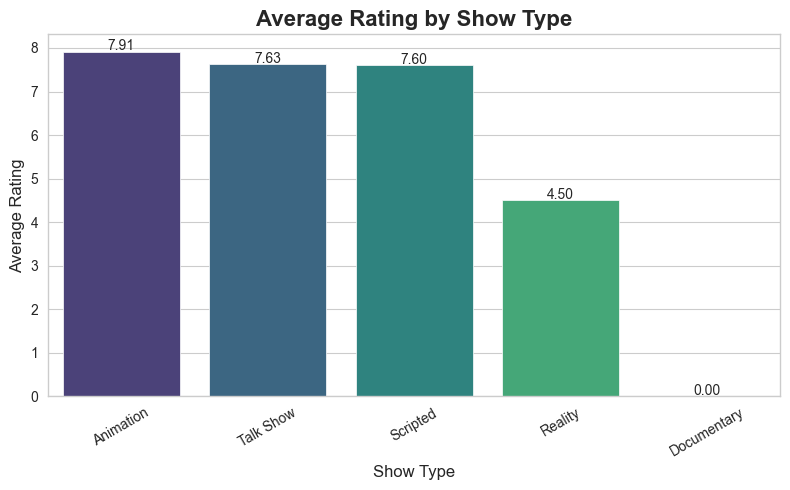

In [17]:
# Calculate average rating by show type
avg_rating = (
    df.groupby("type")["rating_average"]
    .mean()
    .sort_values(ascending=False)
)

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

# Create barplot
sns.barplot(
    x=avg_rating.index,
    y=avg_rating.values,
    palette="viridis"
)

# Add value labels on bars
for i, value in enumerate(avg_rating.values):
    plt.text(i, value + 0.03, f"{value:.2f}", ha='center', fontsize=10)

# Titles and labels
plt.title("Average Rating by Show Type", fontsize=16, fontweight='bold')
plt.xlabel("Show Type", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

# Improve x-axis readability
plt.xticks(rotation=30)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### Insight:

Ratings are fairly similar across most types.
Animation, Talk Show, and Scripted shows have slightly higher averages (~7.6–7.9).
Reality shows perform significantly lower (~4.5).
Documentary shows appear inconsistent (possibly missing or low data).

👉 Conclusion:

Show type influences rating slightly, but not dramatically (except Reality shows).

### Line Chart (Seaborn)
Number of Shows Premiered Each Year

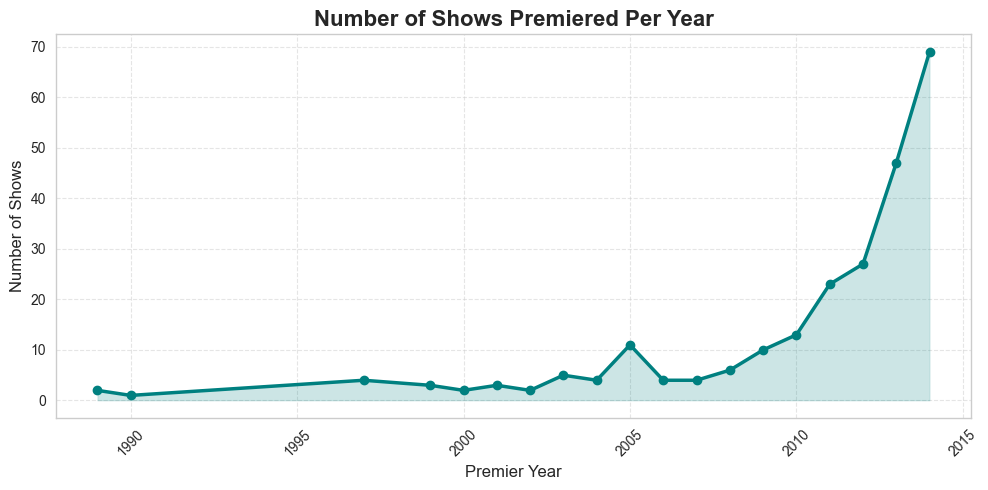

In [19]:
# Count shows premiered each year
shows_per_year = (
    df["premier_year"]
    .value_counts()
    .sort_index()
)

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10, 5))

# Line plot
plt.plot(
    shows_per_year.index,
    shows_per_year.values,
    marker='o',
    linewidth=2.5,
    color='teal'
)

# Fill area under line
plt.fill_between(
    shows_per_year.index,
    shows_per_year.values,
    color='teal',
    alpha=0.2
)

# Titles and labels
plt.title(
    "Number of Shows Premiered Per Year",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Premier Year", fontsize=12)
plt.ylabel("Number of Shows", fontsize=12)

# Improve ticks
plt.xticks(rotation=45)

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### Insight:

There is a strong upward trend over time.
Very few shows existed in early years.
Sharp growth after ~2010.
Peak production occurs in recent years.

👉 Conclusion:

The industry has experienced rapid expansion in recent years, likely due to streaming platforms.

### Histogram (Seaborn)
Distribution of Ratings

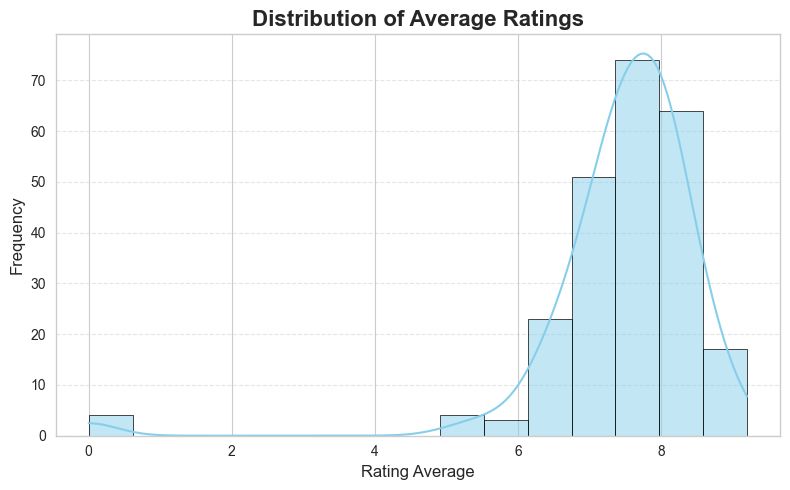

In [21]:
# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

# Histogram with KDE curve
sns.histplot(
    data=df,
    x="rating_average",
    bins=15,
    kde=True,
    color="skyblue",
    edgecolor="black"
)

# Titles and labels
plt.title(
    "Distribution of Average Ratings",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Rating Average", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

### Scatter Plot (Matplotlib)
Summary Word Count vs Rating

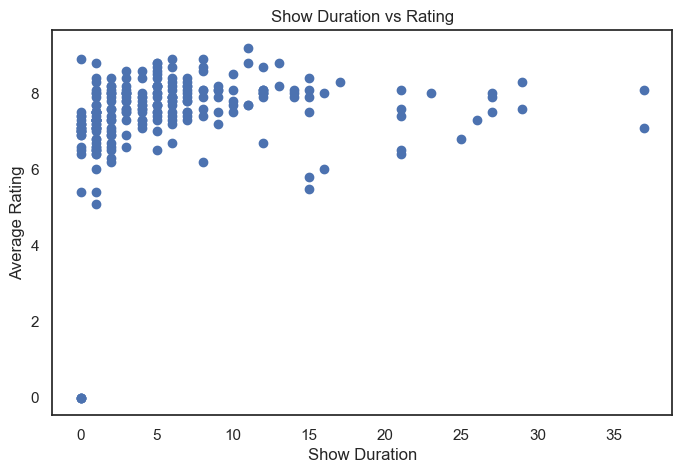

In [27]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["show_duration_years"],
    df["rating_average"]
)

plt.title("Show Duration vs Rating")
plt.xlabel("Show Duration")
plt.ylabel("Average Rating")

plt.show()

### Insight:

There is no strong relationship between show duration and rating.
Most shows (short or long) cluster around ratings 7–8.
Very long shows do not guarantee higher ratings.
A few outliers exist (low-rated or unusually long shows), but they are rare.

👉 Conclusion:

Show duration is not a strong predictor of quality (rating).

### Box Plot (Seaborn)
Rating Distribution by Rating Category

C:\Users\sumit\AppData\Local\Temp\ipykernel_18836\197759888.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


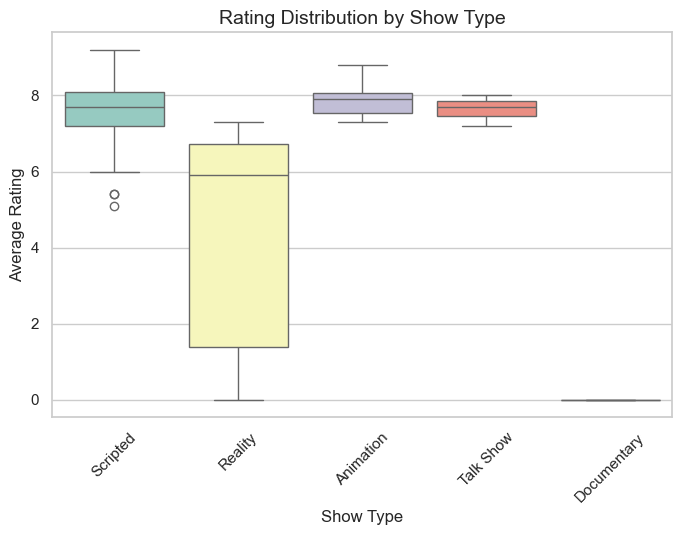

In [25]:
# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(8, 5))

# Boxplot: Rating Average by Show Type
sns.boxplot(
    data=df,
    x="type",
    y="rating_average",
    palette="Set3"
)

# Titles and labels
plt.title("Rating Distribution by Show Type", fontsize=14)
plt.xlabel("Show Type", fontsize=12)
plt.ylabel("Average Rating", fontsize=12)

# Rotate labels if needed
plt.xticks(rotation=45)

# Show plot
plt.show()

### Insight:

Animation and Scripted shows have stable high ratings (low variance).
Reality shows have wide spread and lower median → inconsistent quality.
Talk Shows are relatively consistent but slightly lower than animation.
Outliers exist in nearly every category.

👉 Conclusion:

Animation and scripted content are the most reliable in quality.

### Heatmap (Seaborn)
Correlation Heatmap

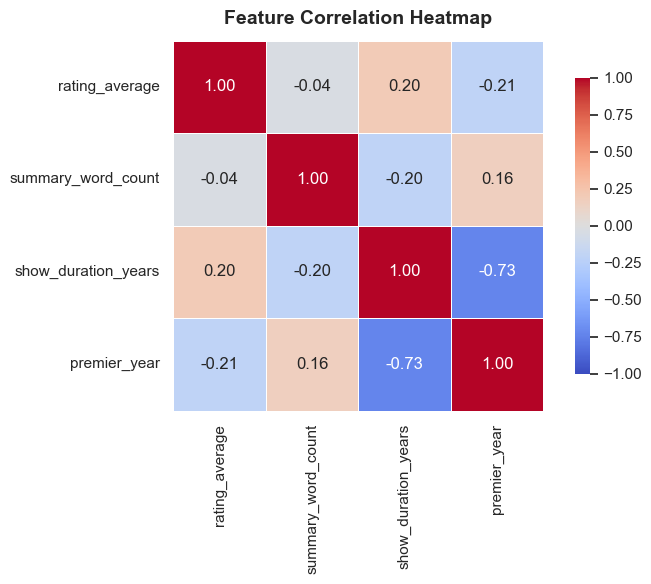

In [26]:
# Select numeric columns
numeric_cols = df[
    ["rating_average",
     "summary_word_count",
     "show_duration_years",
     "premier_year"]
]

# Correlation matrix
correlation = numeric_cols.corr()

# Set style
sns.set_theme(style="white")

# Create figure
plt.figure(figsize=(8, 6))

# Heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",              # show 2 decimal places
    cmap="coolwarm",
    vmin=-1, vmax=1,        # fix scale for proper comparison
    linewidths=0.5,         # add separation between cells
    square=True,            # make cells square
    cbar_kws={"shrink": 0.8}
)

# Title
plt.title(
    "Feature Correlation Heatmap",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

### Insight:

show_duration_years vs premier_year: strong negative correlation (-0.73)
→ newer shows tend to have shorter durations.
rating_average has:
very weak relationship with other features (almost independent)
summary_word_count has almost no impact on rating

👉 Conclusion:

Ratings are mostly independent of other numeric features, except weak trends.